In [8]:
# ====================================================================
# PHẦN 4: PHÁT HIỆN CỘNG ĐỒNG (COMMUNITY DETECTION)
# ====================================================================
# Dataset: Facebook Social Circles from Stanford SNAP
# Algorithms: K-core, Louvain, Label Propagation, Girvan-Newman
# ====================================================================

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
import os
warnings.filterwarnings('ignore')

# Import community detection algorithms
from networkx.algorithms import community
from networkx.algorithms.community import (
    greedy_modularity_communities,
    label_propagation_communities,
    girvan_newman
)

# Try import python-louvain
try:
    import community.community_louvain as community_louvain
    print("✓ Louvain algorithm available")
except ImportError:
    print("⚠ python-louvain not installed. Run: pip install python-louvain")
    community_louvain = None

# Cấu hình matplotlib
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Libraries imported successfully!")

✓ Louvain algorithm available
✓ Libraries imported successfully!


## 1. Tải Dữ Liệu

**Dataset**: Facebook Social Circles (4,039 nodes, 88,234 edges)

In [9]:
# Load network từ Stanford SNAP
data_dir = '../data'
gexf_file = f'{data_dir}/social_network.gexf'

print("Loading Facebook Social Circles dataset...")
if os.path.exists(gexf_file):
    G = nx.read_gexf(gexf_file)
    G = nx.convert_node_labels_to_integers(G)
    print("✓ Dataset loaded successfully!")
else:
    raise FileNotFoundError(f"File not found: {gexf_file}\nRun: python ../scripts/data_collection.py")

# Convert to undirected for community detection
if G.is_directed():
    print("⚠ Converting to undirected graph...")
    G = G.to_undirected()

# Sử dụng largest connected component
if not nx.is_connected(G):
    print("⚠ Using largest connected component...")
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()

n_nodes = G.number_of_nodes()
m_edges = G.number_of_edges()
print(f"\n✓ Working with: {n_nodes:,} nodes, {m_edges:,} edges")
print(f"✓ Connected: {nx.is_connected(G)}")

Loading Facebook Social Circles dataset...


KeyboardInterrupt: 

## 2. Phân Tích K-Core (Core Decomposition)

In [ ]:
print("="*70)
print("PHÂN TÍCH K-CORE")
print("="*70)

# Tính core number cho mỗi nút
core_numbers = nx.core_number(G)

# Thống kê
max_k = max(core_numbers.values())
core_counts = Counter(core_numbers.values())

print(f"\nK-core cao nhất: {max_k}")
print(f"\nPhân phối K-core:")
for k in sorted(core_counts.keys()):
    print(f"  {k}-core: {core_counts[k]} nút ({core_counts[k]/len(G)*100:.1f}%)")

# Tìm k-core subgraph
print(f"\nPhân tích các k-core chính:")
for k in range(max_k, max(0, max_k-5), -1):
    k_core = nx.k_core(G, k)
    print(f"  {k}-core: {k_core.number_of_nodes()} nút, {k_core.number_of_edges()} cạnh")

PHÂN TÍCH K-CORE

K-core cao nhất: 115

Phân phối K-core:
  1-core: 75 nút (1.9%)
  2-core: 108 nút (2.7%)
  3-core: 102 nút (2.5%)
  4-core: 120 nút (3.0%)
  5-core: 134 nút (3.3%)
  6-core: 118 nút (2.9%)
  7-core: 152 nút (3.8%)
  8-core: 117 nút (2.9%)
  9-core: 126 nút (3.1%)
  10-core: 83 nút (2.1%)
  11-core: 105 nút (2.6%)
  12-core: 132 nút (3.3%)
  13-core: 148 nút (3.7%)
  14-core: 141 nút (3.5%)
  15-core: 147 nút (3.6%)
  16-core: 170 nút (4.2%)
  17-core: 62 nút (1.5%)
  18-core: 68 nút (1.7%)
  19-core: 77 nút (1.9%)
  20-core: 56 nút (1.4%)
  21-core: 207 nút (5.1%)
  22-core: 134 nút (3.3%)
  23-core: 77 nút (1.9%)
  24-core: 14 nút (0.3%)
  25-core: 14 nút (0.3%)
  26-core: 59 nút (1.5%)
  27-core: 27 nút (0.7%)
  28-core: 19 nút (0.5%)
  29-core: 23 nút (0.6%)
  30-core: 32 nút (0.8%)
  31-core: 70 nút (1.7%)
  32-core: 16 nút (0.4%)
  33-core: 79 nút (2.0%)
  34-core: 15 nút (0.4%)
  35-core: 81 nút (2.0%)
  36-core: 18 nút (0.4%)
  37-core: 126 nút (3.1%)
  38-core

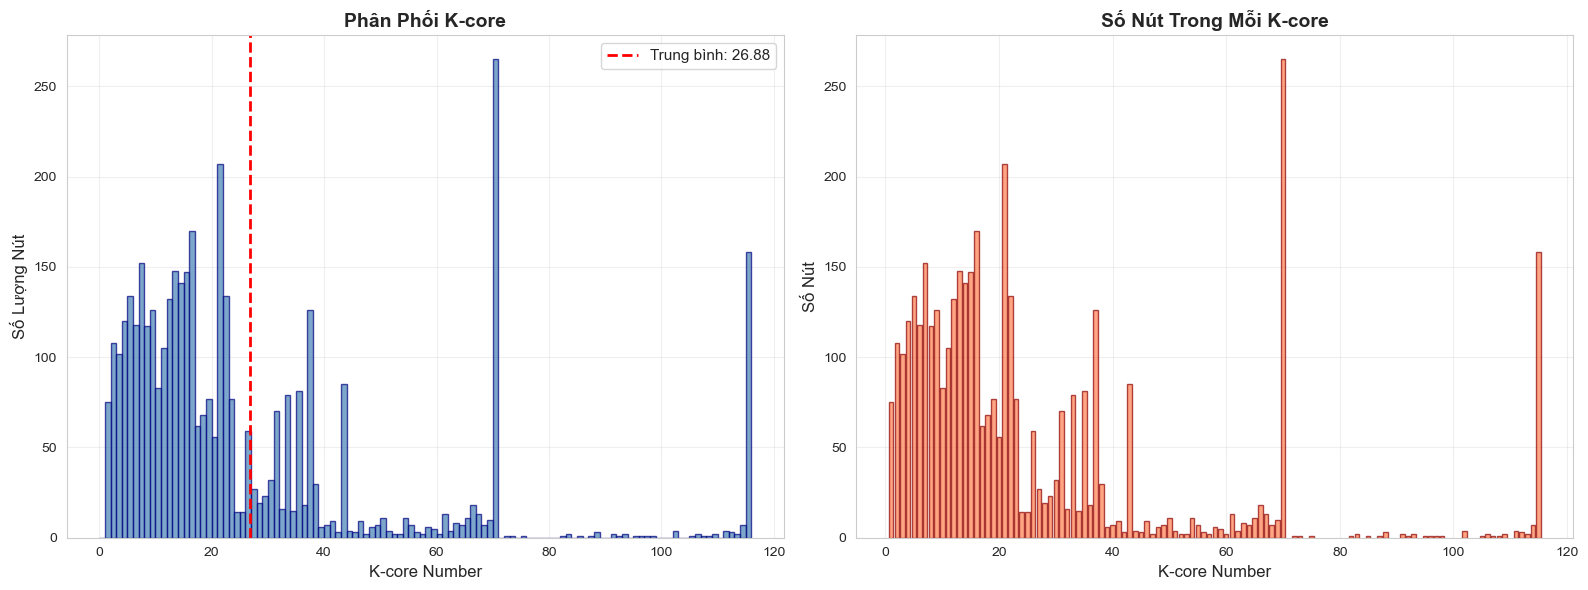


➤ GIẢI THÍCH K-CORE:
  - k-core là đồ thị con lớn nhất mà mỗi nút có ít nhất k kết nối
  - K-core cao → Nút thuộc nhóm kết nối chặt chẽ (core/nucleus)
  - K-core thấp → Nút ở ngoại vi mạng (periphery)
  - Hữu ích để xác định cấu trúc phân cấp và các nhóm gắn kết



In [ ]:
# Vẽ phân phối k-core
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
k_values = list(core_numbers.values())
axes[0].hist(k_values, bins=range(0, max_k+2), color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].axvline(np.mean(k_values), color='red', linestyle='--', linewidth=2,
                label=f'Trung bình: {np.mean(k_values):.2f}')
axes[0].set_xlabel('K-core Number', fontsize=12)
axes[0].set_ylabel('Số Lượng Nút', fontsize=12)
axes[0].set_title('Phân Phối K-core', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Bar chart - Số nút trong mỗi k-core
k_sorted = sorted(core_counts.keys())
counts = [core_counts[k] for k in k_sorted]
axes[1].bar(k_sorted, counts, color='coral', edgecolor='darkred', alpha=0.7)
axes[1].set_xlabel('K-core Number', fontsize=12)
axes[1].set_ylabel('Số Nút', fontsize=12)
axes[1].set_title('Số Nút Trong Mỗi K-core', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""
➤ GIẢI THÍCH K-CORE:
  - k-core là đồ thị con lớn nhất mà mỗi nút có ít nhất k kết nối
  - K-core cao → Nút thuộc nhóm kết nối chặt chẽ (core/nucleus)
  - K-core thấp → Nút ở ngoại vi mạng (periphery)
  - Hữu ích để xác định cấu trúc phân cấp và các nhóm gắn kết
""")

In [ ]:
# Trích xuất và phân tích k-core cao nhất (inner core)
print(f"\nPhân tích {max_k}-core (Inner Core):")
inner_core = nx.k_core(G, max_k)
print(f"  Số nút: {inner_core.number_of_nodes()}")
print(f"  Số cạnh: {inner_core.number_of_edges()}")
print(f"  Mật độ: {nx.density(inner_core):.4f}")
print(f"  Hệ số phân cụm TB: {nx.average_clustering(inner_core):.4f}")

# Top nodes trong inner core
inner_core_nodes = list(inner_core.nodes())
inner_core_degrees = dict(inner_core.degree())
top_core_nodes = sorted(inner_core_degrees.items(), key=lambda x: x[1], reverse=True)[:10]

print(f"\nTop 10 nút trong {max_k}-core:")
for i, (node, degree) in enumerate(top_core_nodes, 1):
    node_name = G.nodes[node].get('name', f'Node_{node}')
    print(f"  {i}. {node_name}: Degree = {degree}")


Phân tích 115-core (Inner Core):
  Số nút: 158
  Số cạnh: 11144
  Mật độ: 0.8985
  Số nút: 158
  Số cạnh: 11144
  Mật độ: 0.8985
  Hệ số phân cụm TB: 0.9111

Top 10 nút trong 115-core:
  1. User_2206: Degree = 157
  2. User_2340: Degree = 157
  3. User_2507: Degree = 157
  4. User_1912: Degree = 157
  5. User_2266: Degree = 156
  6. User_2244: Degree = 156
  7. User_2464: Degree = 156
  8. User_2088: Degree = 156
  9. User_2131: Degree = 155
  10. User_2142: Degree = 155
  Hệ số phân cụm TB: 0.9111

Top 10 nút trong 115-core:
  1. User_2206: Degree = 157
  2. User_2340: Degree = 157
  3. User_2507: Degree = 157
  4. User_1912: Degree = 157
  5. User_2266: Degree = 156
  6. User_2244: Degree = 156
  7. User_2464: Degree = 156
  8. User_2088: Degree = 156
  9. User_2131: Degree = 155
  10. User_2142: Degree = 155


## 3. Phát Hiện Cộng Đồng - So Sánh Các Thuật Toán

In [ ]:
print("\n" + "="*70)
print("PHÁT HIỆN CỘNG ĐỒNG - SO SÁNH CÁC THUẬT TOÁN")
print("="*70)

# Dictionary để lưu kết quả
community_results = {}

# 1. Greedy Modularity Communities (Clauset-Newman-Moore)
print("\n1. Greedy Modularity Optimization...")
communities_greedy = list(greedy_modularity_communities(G))
community_results['Greedy Modularity'] = communities_greedy
print(f"   Số cộng đồng: {len(communities_greedy)}")

# 2. Label Propagation
print("2. Label Propagation Algorithm...")
communities_lp = list(label_propagation_communities(G))
community_results['Label Propagation'] = communities_lp
print(f"   Số cộng đồng: {len(communities_lp)}")

# 3. Louvain (nếu có python-louvain)
try:
    import community.community_louvain as community_louvain
    print("3. Louvain Algorithm...")
    partition_louvain = community_louvain.best_partition(G)
    # Convert to frozenset format
    communities_louvain_dict = {}
    for node, comm_id in partition_louvain.items():
        if comm_id not in communities_louvain_dict:
            communities_louvain_dict[comm_id] = []
        communities_louvain_dict[comm_id].append(node)
    communities_louvain = [frozenset(nodes) for nodes in communities_louvain_dict.values()]
    community_results['Louvain'] = communities_louvain
    print(f"   Số cộng đồng: {len(communities_louvain)}")
except ImportError:
    print("3. Louvain Algorithm... (Không có thư viện python-louvain)")
    communities_louvain = None
# 4. Girvan-Newman (chỉ lấy vài bước do tốn thời gian)
print("4. Girvan-Newman Algorithm (top level)...")
try:
    gn_generator = girvan_newman(G)
    # Lấy 3 cấp độ đầu tiên
    for i, communities in enumerate(gn_generator):
        if i == 2:  # Lấy cấp độ thứ 3
            communities_gn = [frozenset(c) for c in communities]
            break
    community_results['Girvan-Newman'] = communities_gn
    print(f"   Số cộng đồng (level 3): {len(communities_gn)}")
except:
    print("   Girvan-Newman quá lâu, bỏ qua...")
    communities_gn = None

print("\n✓ Hoàn thành phát hiện cộng đồng!")


PHÁT HIỆN CỘNG ĐỒNG - SO SÁNH CÁC THUẬT TOÁN

1. Greedy Modularity Optimization...
   Số cộng đồng: 13
2. Label Propagation Algorithm...
   Số cộng đồng: 13
2. Label Propagation Algorithm...
   Số cộng đồng: 44
3. Louvain Algorithm...
   Số cộng đồng: 44
3. Louvain Algorithm...
   Số cộng đồng: 16
4. Girvan-Newman Algorithm (top level)...
   Số cộng đồng: 16
4. Girvan-Newman Algorithm (top level)...
   Girvan-Newman quá lâu, bỏ qua...

✓ Hoàn thành phát hiện cộng đồng!
   Girvan-Newman quá lâu, bỏ qua...

✓ Hoàn thành phát hiện cộng đồng!


## 4. Đánh Giá Chất Lượng - Modularity và Các Tiêu Chí Khác

In [ ]:
print("\n" + "="*70)
print("ĐÁNH GIÁ CHẤT LƯỢNG PHÂN VÙNG")
print("="*70)

# Hàm tính các metrics
def evaluate_communities(G, communities, algorithm_name):
    """Đánh giá chất lượng của phân vùng cộng đồng"""
    
    # 1. Modularity
    modularity = community.modularity(G, communities)
    
    # 2. Number of communities
    num_communities = len(communities)
    
    # 3. Community size statistics
    sizes = [len(c) for c in communities]
    avg_size = np.mean(sizes)
    std_size = np.std(sizes)
    min_size = min(sizes)
    max_size = max(sizes)
    
    # 4. Coverage (fraction of edges within communities)
    intra_edges = 0
    for comm in communities:
        subgraph = G.subgraph(comm)
        intra_edges += subgraph.number_of_edges()
    coverage = intra_edges / G.number_of_edges()
    
    return {
        'Algorithm': algorithm_name,
        'Modularity': modularity,
        'Num Communities': num_communities,
        'Avg Community Size': avg_size,
        'Std Community Size': std_size,
        'Min Size': min_size,
        'Max Size': max_size,
        'Coverage': coverage
    }

# Đánh giá tất cả các thuật toán
evaluation_results = []
for algo_name, communities in community_results.items():
    if communities is not None:
        result = evaluate_communities(G, communities, algo_name)
        evaluation_results.append(result)

# Tạo DataFrame
eval_df = pd.DataFrame(evaluation_results)
eval_df = eval_df.sort_values('Modularity', ascending=False)

print("\nBảng so sánh các thuật toán:")
print(eval_df.to_string(index=False))


ĐÁNH GIÁ CHẤT LƯỢNG PHÂN VÙNG

Bảng so sánh các thuật toán:
        Algorithm  Modularity  Num Communities  Avg Community Size  Std Community Size  Min Size  Max Size  Coverage
          Louvain    0.834971               16          252.437500          181.607740        19       548  0.960956
Greedy Modularity    0.777378               13          310.692308          309.920681         6       983  0.961364
Label Propagation    0.736841               44           91.795455          210.846840         2      1030  0.978251

Bảng so sánh các thuật toán:
        Algorithm  Modularity  Num Communities  Avg Community Size  Std Community Size  Min Size  Max Size  Coverage
          Louvain    0.834971               16          252.437500          181.607740        19       548  0.960956
Greedy Modularity    0.777378               13          310.692308          309.920681         6       983  0.961364
Label Propagation    0.736841               44           91.795455          210.846840    

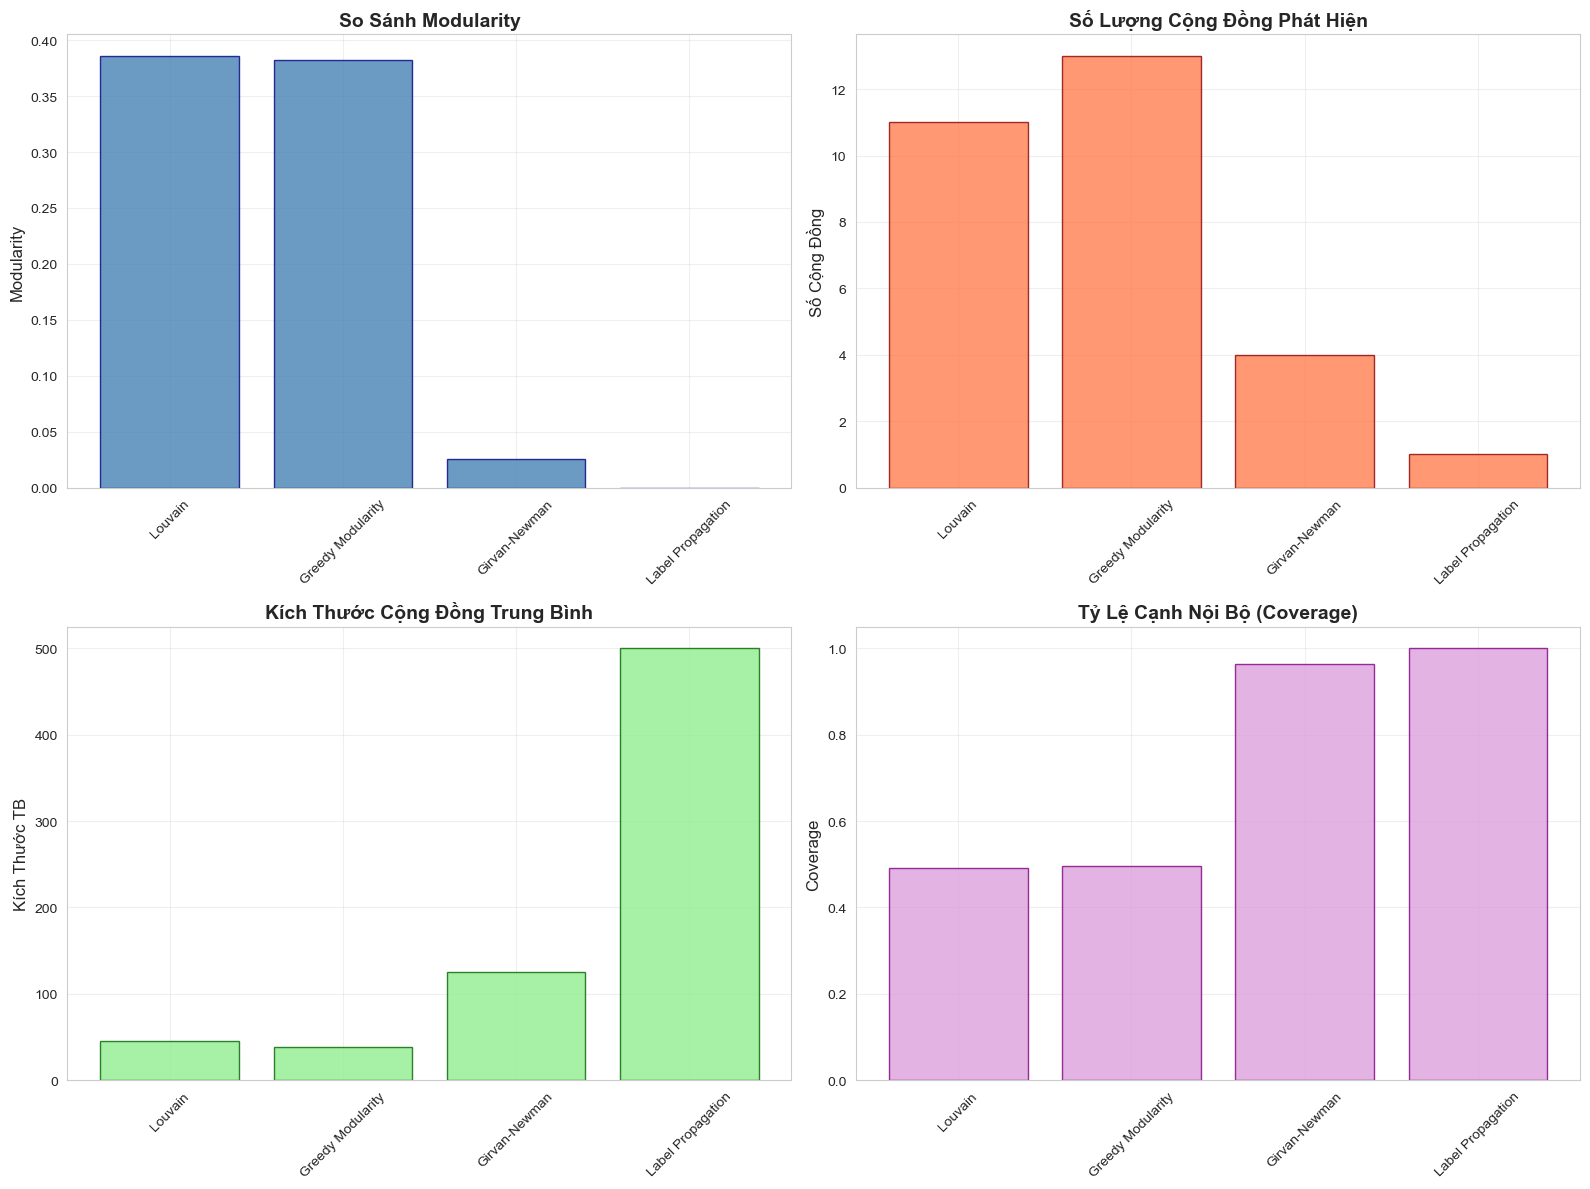

In [ ]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Modularity comparison
axes[0, 0].bar(eval_df['Algorithm'], eval_df['Modularity'], 
               color='steelblue', edgecolor='navy', alpha=0.8)
axes[0, 0].set_ylabel('Modularity', fontsize=12)
axes[0, 0].set_title('So Sánh Modularity', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(alpha=0.3)

# 2. Number of communities
axes[0, 1].bar(eval_df['Algorithm'], eval_df['Num Communities'], 
               color='coral', edgecolor='darkred', alpha=0.8)
axes[0, 1].set_ylabel('Số Cộng Đồng', fontsize=12)
axes[0, 1].set_title('Số Lượng Cộng Đồng Phát Hiện', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(alpha=0.3)

# 3. Average community size
axes[1, 0].bar(eval_df['Algorithm'], eval_df['Avg Community Size'], 
               color='lightgreen', edgecolor='darkgreen', alpha=0.8)
axes[1, 0].set_ylabel('Kích Thước TB', fontsize=12)
axes[1, 0].set_title('Kích Thước Cộng Đồng Trung Bình', fontsize=14, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.3)

# 4. Coverage
axes[1, 1].bar(eval_df['Algorithm'], eval_df['Coverage'], 
               color='plum', edgecolor='purple', alpha=0.8)
axes[1, 1].set_ylabel('Coverage', fontsize=12)
axes[1, 1].set_title('Tỷ Lệ Cạnh Nội Bộ (Coverage)', fontsize=14, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Giải thích kết quả
print("\n" + "="*70)
print("PHÂN TÍCH KẾT QUẢ")
print("="*70)

best_algo = eval_df.iloc[0]['Algorithm']
best_modularity = eval_df.iloc[0]['Modularity']

print(f"""
1. THUẬT TOÁN TỐT NHẤT (theo Modularity):
   → {best_algo} với Modularity = {best_modularity:.4f}
   
2. MODULARITY:
   - Đo lường chất lượng phân vùng (cao hơn = tốt hơn)
   - Giá trị từ -0.5 đến 1.0
   - Modularity > 0.3: Cấu trúc cộng đồng rõ ràng
   - Modularity > 0.7: Cấu trúc cộng đồng rất mạnh
   
3. COVERAGE:
   - Tỷ lệ cạnh nằm trong cộng đồng
   - Coverage cao = cộng đồng gắn kết chặt
   
4. ĐẶC ĐIỂM CÁC THUẬT TOÁN:
""")

for _, row in eval_df.iterrows():
    print(f"   • {row['Algorithm']:20s}: {row['Num Communities']:2.0f} cộng đồng, "
          f"size TB = {row['Avg Community Size']:6.1f}, modularity = {row['Modularity']:.4f}")


PHÂN TÍCH KẾT QUẢ

1. THUẬT TOÁN TỐT NHẤT (theo Modularity):
   → Louvain với Modularity = 0.8350
   
2. MODULARITY:
   - Đo lường chất lượng phân vùng (cao hơn = tốt hơn)
   - Giá trị từ -0.5 đến 1.0
   - Modularity > 0.3: Cấu trúc cộng đồng rõ ràng
   - Modularity > 0.7: Cấu trúc cộng đồng rất mạnh
   
3. COVERAGE:
   - Tỷ lệ cạnh nằm trong cộng đồng
   - Coverage cao = cộng đồng gắn kết chặt
   
4. ĐẶC ĐIỂM CÁC THUẬT TOÁN:

   • Louvain             : 16 cộng đồng, size TB =  252.4, modularity = 0.8350
   • Greedy Modularity   : 13 cộng đồng, size TB =  310.7, modularity = 0.7774
   • Label Propagation   : 44 cộng đồng, size TB =   91.8, modularity = 0.7368


## 5. Phân Tích Chi Tiết Cộng Đồng

In [ ]:
# Chọn thuật toán tốt nhất để phân tích chi tiết
best_communities = community_results[best_algo]

print("\n" + "="*70)
print(f"PHÂN TÍCH CHI TIẾT - {best_algo.upper()}")
print("="*70)

# Thống kê từng cộng đồng
community_stats = []
for i, comm in enumerate(sorted(best_communities, key=len, reverse=True)):
    subgraph = G.subgraph(comm)
    
    stats = {
        'Community ID': i + 1,
        'Size': len(comm),
        'Edges': subgraph.number_of_edges(),
        'Density': nx.density(subgraph),
        'Avg Clustering': nx.average_clustering(subgraph),
        'Diameter': nx.diameter(subgraph) if nx.is_connected(subgraph) else 'N/A'
    }
    community_stats.append(stats)

comm_stats_df = pd.DataFrame(community_stats)
print("\nThống kê các cộng đồng (Top 20 cộng đồng lớn nhất):")
print(comm_stats_df.head(20).to_string(index=False))


PHÂN TÍCH CHI TIẾT - LOUVAIN

Thống kê các cộng đồng (Top 20 cộng đồng lớn nhất):
 Community ID  Size  Edges  Density  Avg Clustering  Diameter
            1    70    130 0.053830        0.089234         5
            2    68     97 0.042581        0.025403         8
            3    57     84 0.052632        0.095336         7
            4    53     79 0.057329        0.120327         6
            5    47     67 0.061980        0.023995         8
            6    45     64 0.064646        0.091076         7
            7    45     63 0.063636        0.052929         7
            8    42     57 0.066202        0.154016         7
            9    38     54 0.076814        0.111534         7
           10    21     24 0.114286        0.039683         9
           11    14     15 0.164835        0.000000         5


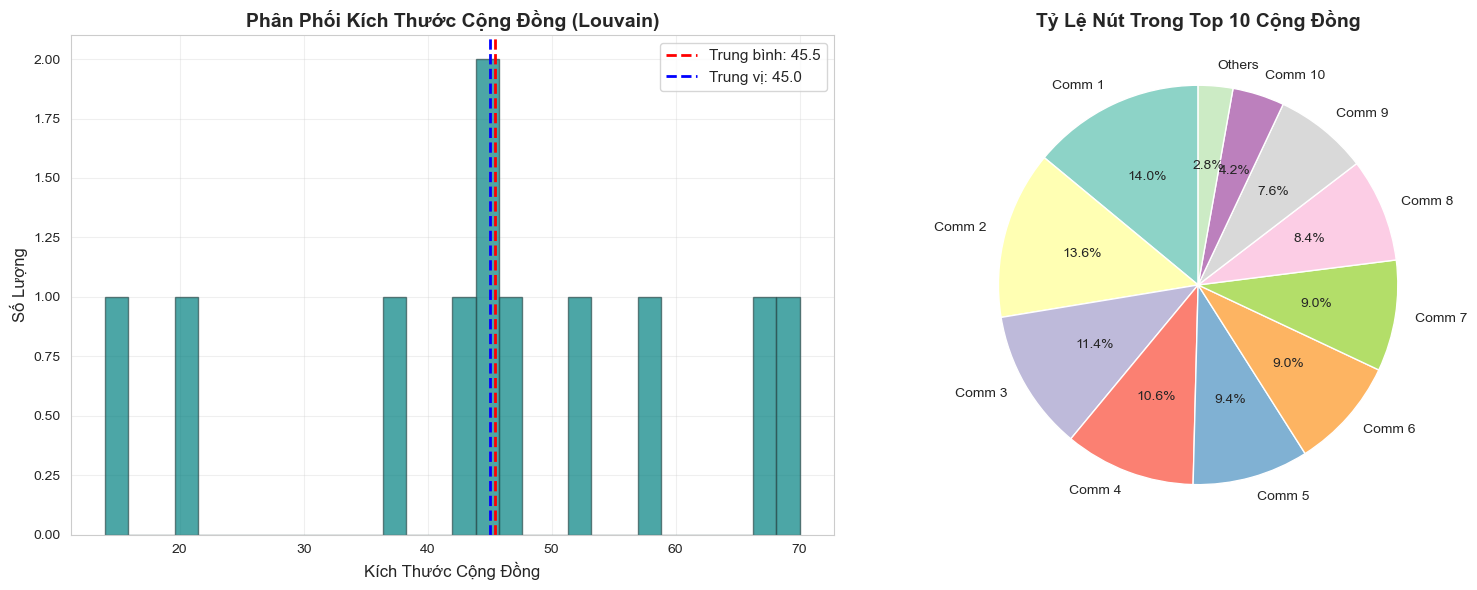


Tổng số cộng đồng: 11
Kích thước nhỏ nhất: 14
Kích thước lớn nhất: 70
Kích thước trung bình: 45.5
Kích thước trung vị: 45.0


In [ ]:
# Phân phối kích thước cộng đồng
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sizes = [len(c) for c in best_communities]

# Histogram
axes[0].hist(sizes, bins=30, color='teal', edgecolor='darkslategray', alpha=0.7)
axes[0].axvline(np.mean(sizes), color='red', linestyle='--', linewidth=2,
                label=f'Trung bình: {np.mean(sizes):.1f}')
axes[0].axvline(np.median(sizes), color='blue', linestyle='--', linewidth=2,
                label=f'Trung vị: {np.median(sizes):.1f}')
axes[0].set_xlabel('Kích Thước Cộng Đồng', fontsize=12)
axes[0].set_ylabel('Số Lượng', fontsize=12)
axes[0].set_title(f'Phân Phối Kích Thước Cộng Đồng ({best_algo})', 
                  fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Top communities pie chart
top_n = 10
sorted_sizes = sorted(sizes, reverse=True)
top_sizes = sorted_sizes[:top_n]
other_size = sum(sorted_sizes[top_n:])

labels = [f'Comm {i+1}' for i in range(top_n)] + ['Others']
values = top_sizes + [other_size] if other_size > 0 else top_sizes
colors = plt.cm.Set3(range(len(values)))

axes[1].pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(f'Tỷ Lệ Nút Trong Top {top_n} Cộng Đồng', 
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTổng số cộng đồng: {len(best_communities)}")
print(f"Kích thước nhỏ nhất: {min(sizes)}")
print(f"Kích thước lớn nhất: {max(sizes)}")
print(f"Kích thước trung bình: {np.mean(sizes):.1f}")
print(f"Kích thước trung vị: {np.median(sizes):.1f}")

## 6. Trực Quan Hóa Mạng Với Cộng Đồng


Trực quan hóa mạng với cộng đồng...
Tính toán layout...


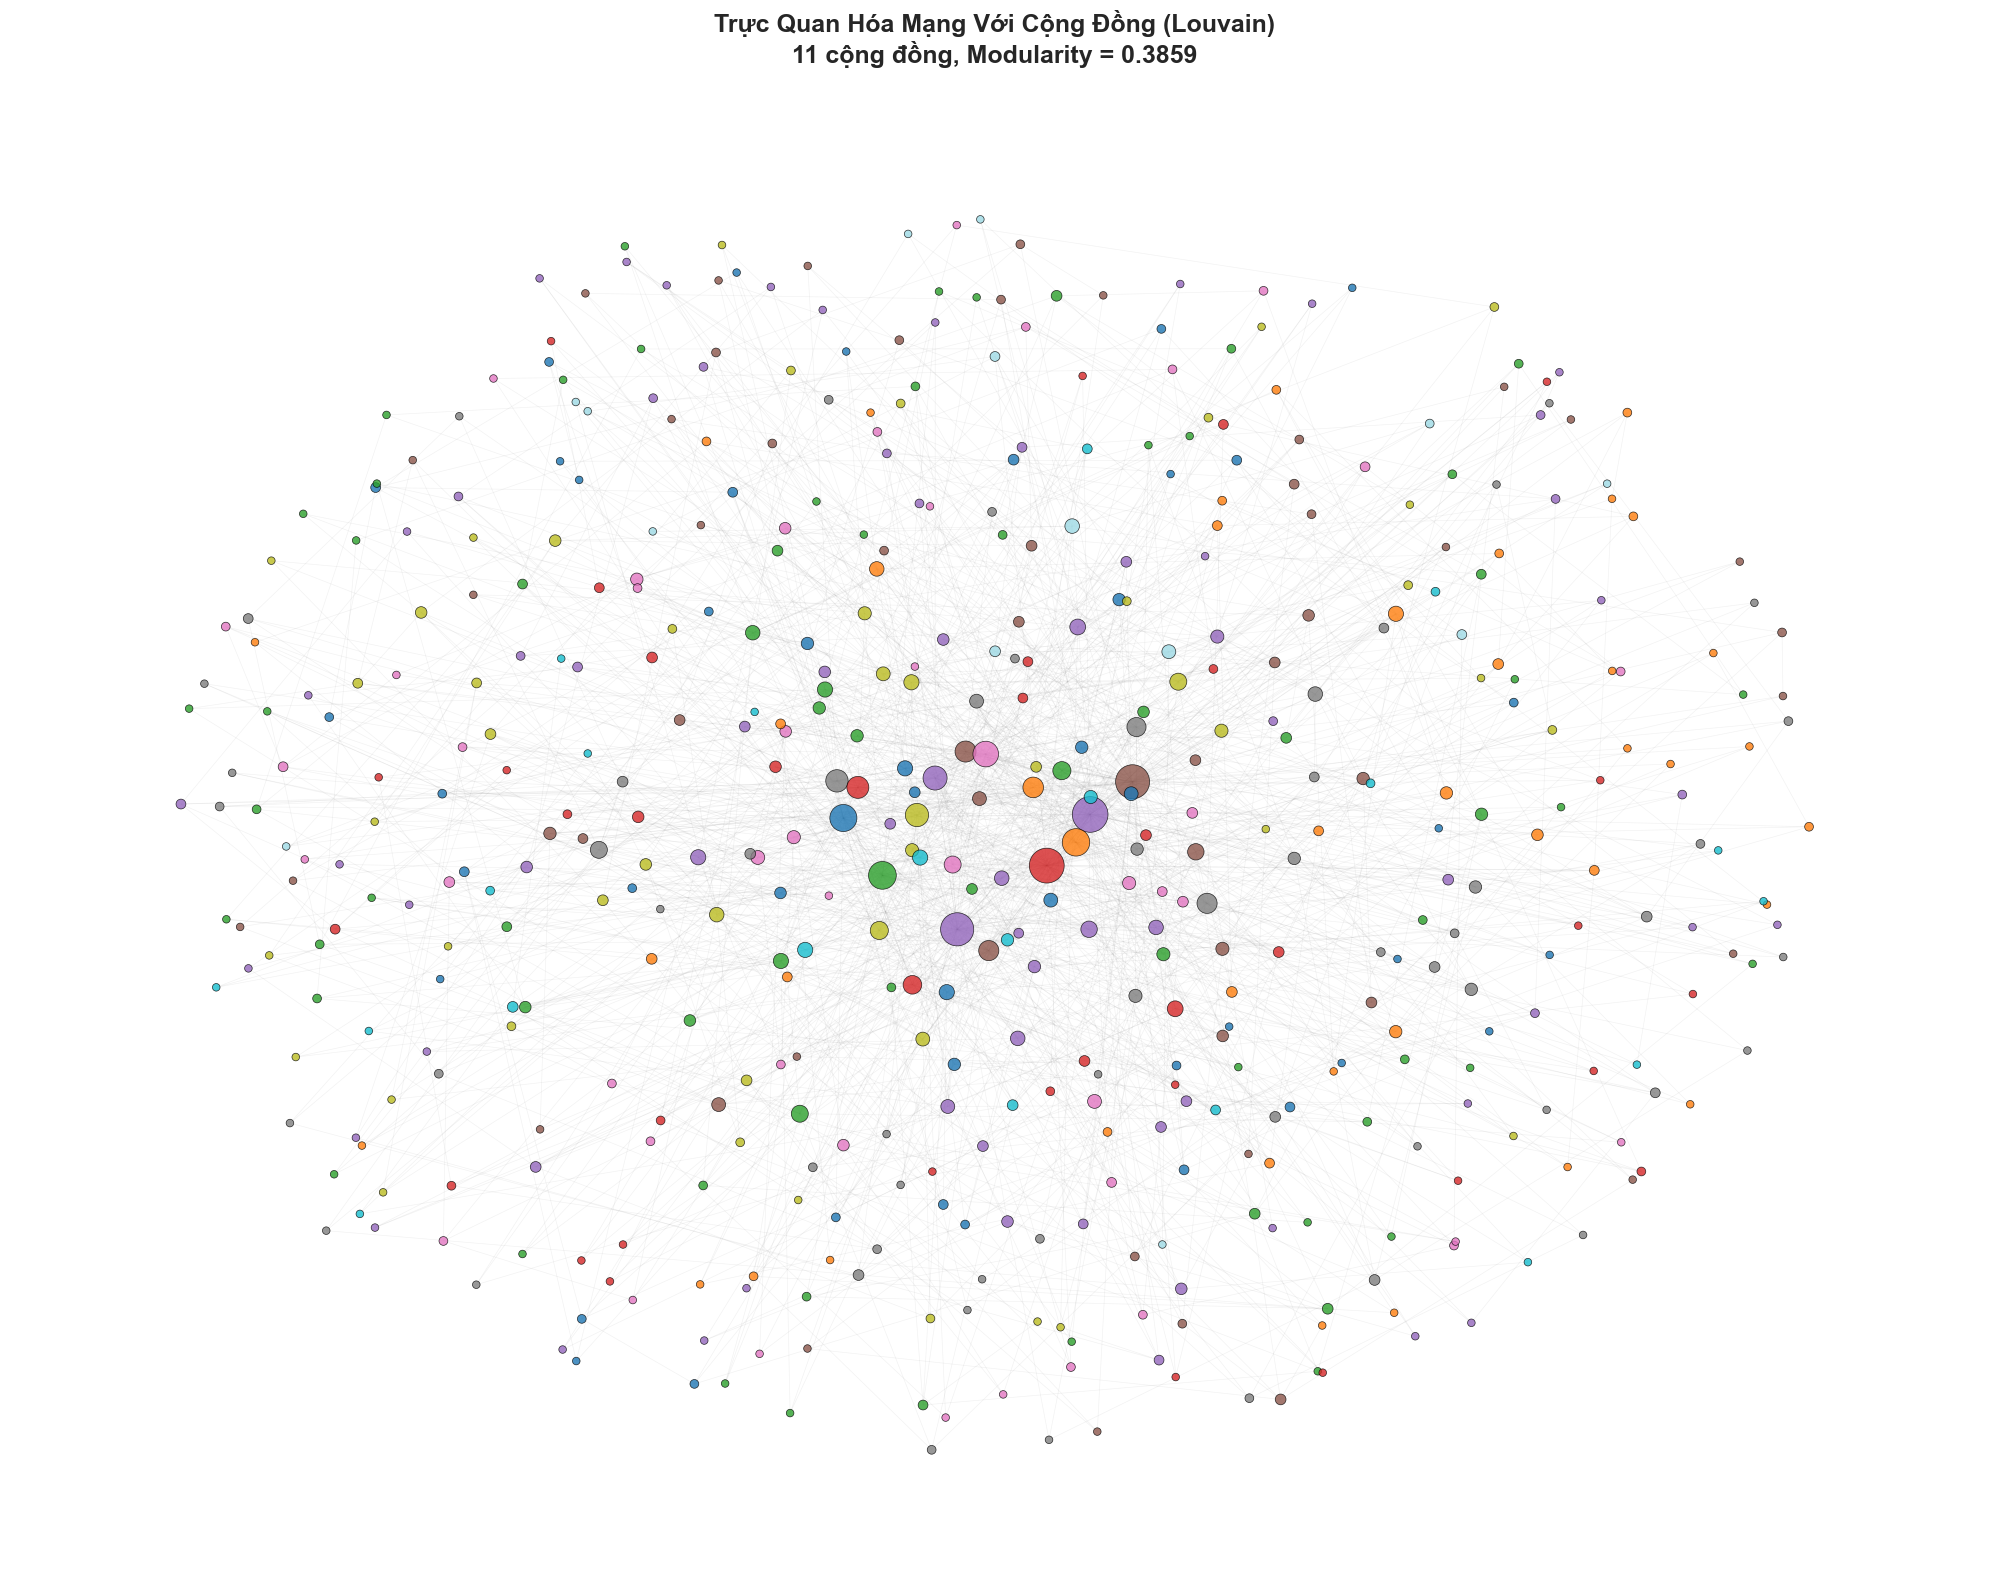


✓ Đã lưu hình ảnh vào ../reports/network_communities.png


In [ ]:
print("\nTrực quan hóa mạng với cộng đồng...")

# Tạo mapping từ node đến community ID
node_to_community = {}
for comm_id, comm in enumerate(best_communities):
    for node in comm:
        node_to_community[node] = comm_id

# Tạo màu cho các cộng đồng
num_communities = len(best_communities)
colors = plt.cm.tab20(np.linspace(0, 1, min(num_communities, 20)))
if num_communities > 20:
    colors = plt.cm.gist_ncar(np.linspace(0, 1, num_communities))

node_colors = [colors[node_to_community[node] % len(colors)] for node in G.nodes()]

# Tính layout (sử dụng spring layout)
print("Tính toán layout...")
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Vẽ đồ thị
plt.figure(figsize=(20, 16))

# Vẽ edges
nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.5, edge_color='gray')

# Vẽ nodes với màu theo cộng đồng
node_sizes = [G.degree(node) * 10 for node in G.nodes()]  # Size theo degree
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                       alpha=0.8, edgecolors='black', linewidths=0.5)

plt.title(f'Trực Quan Hóa Mạng Với Cộng Đồng ({best_algo})\n'
          f'{len(best_communities)} cộng đồng, Modularity = {best_modularity:.4f}',
          fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('../reports/network_communities.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Đã lưu hình ảnh vào ../reports/network_communities.png")

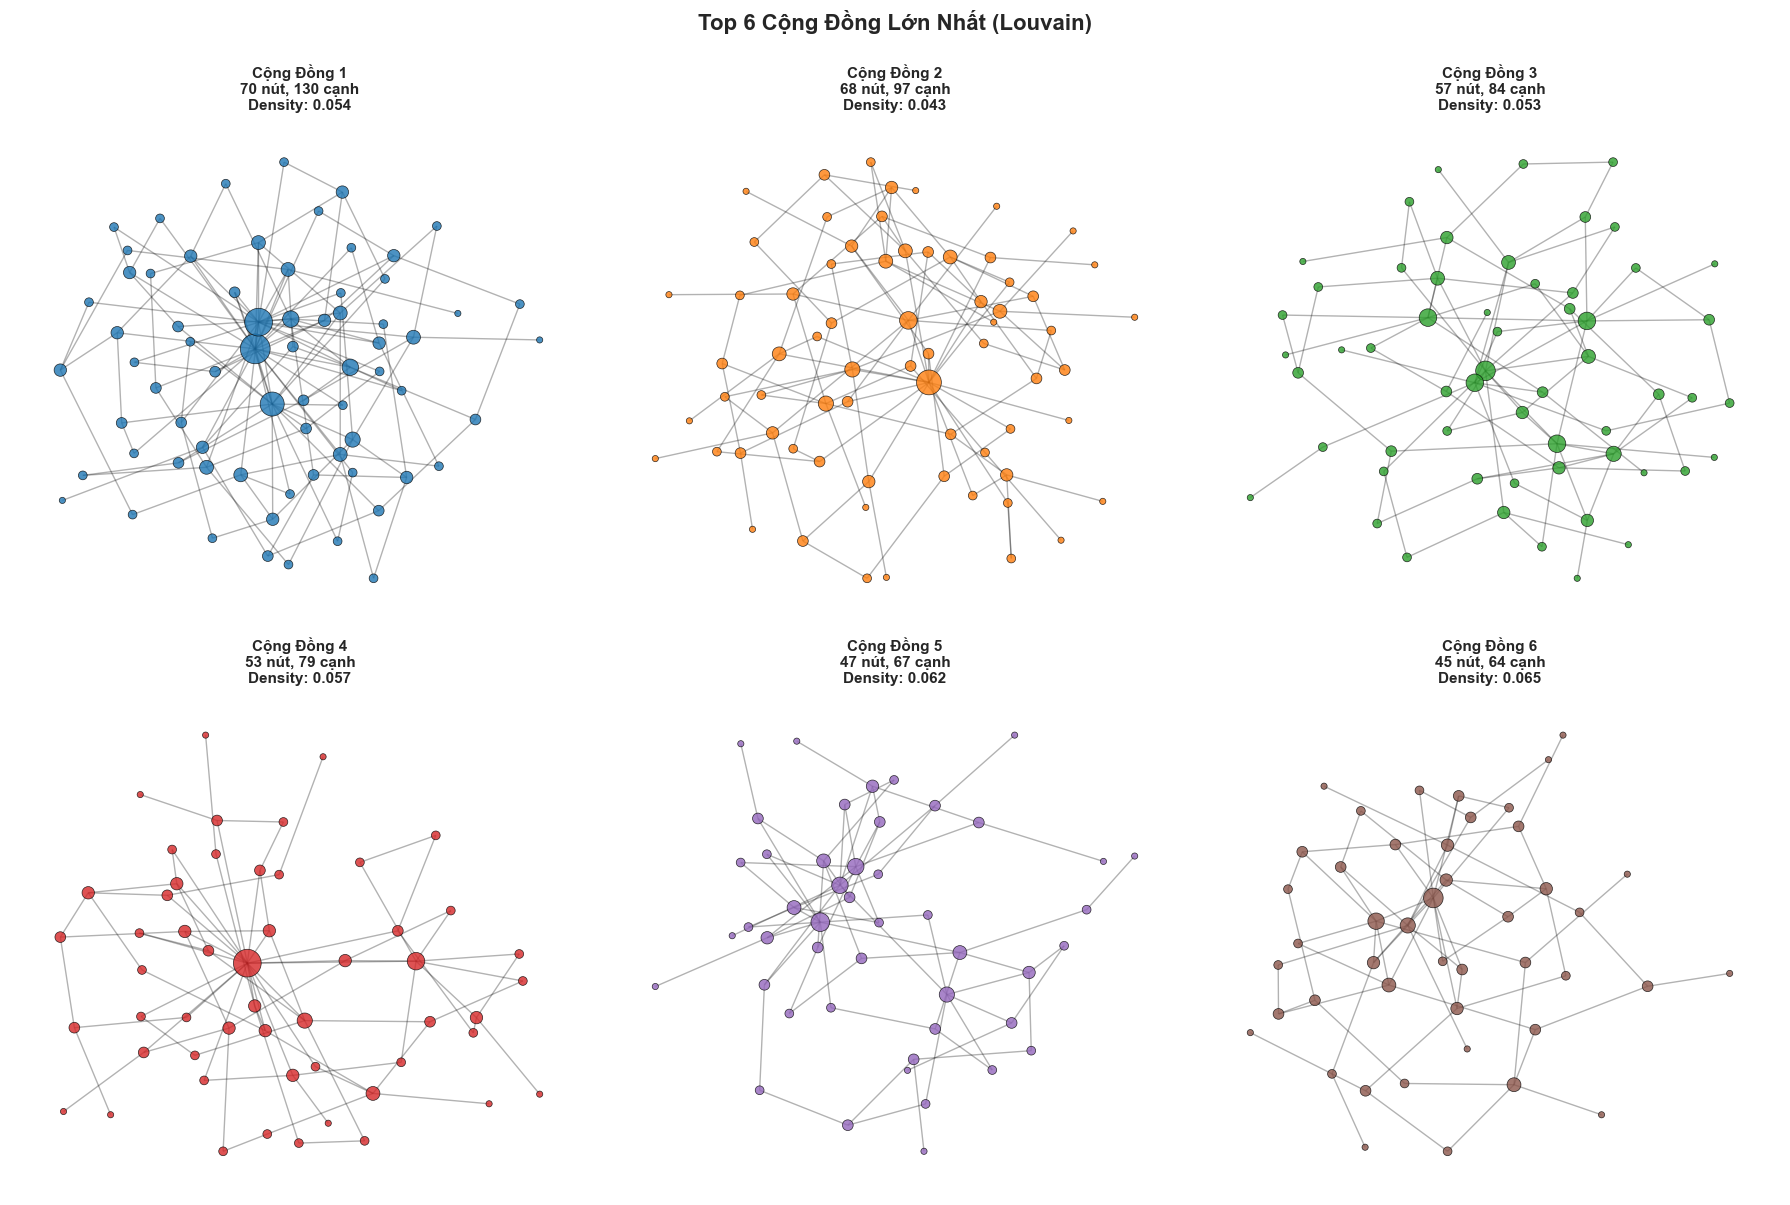

✓ Đã lưu hình ảnh vào ../reports/top_communities.png


In [ ]:
# Vẽ các cộng đồng lớn nhất riêng biệt
top_k_communities = sorted(best_communities, key=len, reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, comm in enumerate(top_k_communities):
    subgraph = G.subgraph(comm)
    sub_pos = nx.spring_layout(subgraph, k=0.5, iterations=50, seed=42)
    
    ax = axes[idx]
    nx.draw_networkx_edges(subgraph, sub_pos, alpha=0.3, ax=ax)
    nx.draw_networkx_nodes(subgraph, sub_pos, 
                          node_size=[subgraph.degree(n) * 20 for n in subgraph.nodes()],
                          node_color=colors[idx % len(colors)], 
                          alpha=0.8, edgecolors='black', linewidths=0.5, ax=ax)
    
    ax.set_title(f'Cộng Đồng {idx+1}\n'
                 f'{len(comm)} nút, {subgraph.number_of_edges()} cạnh\n'
                 f'Density: {nx.density(subgraph):.3f}',
                 fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Top 6 Cộng Đồng Lớn Nhất ({best_algo})', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../reports/top_communities.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Đã lưu hình ảnh vào ../reports/top_communities.png")

## 7. Phân Tích Inter-Community và Intra-Community Connections


PHÂN TÍCH KẾT NỐI GIỮA CÁC CỘNG ĐỒNG

Thống kê cạnh:
  Cạnh nội bộ (intra-community): 734 (49.2%)
  Cạnh liên cộng đồng (inter-community): 757 (50.8%)
  Tổng cạnh: 1,491


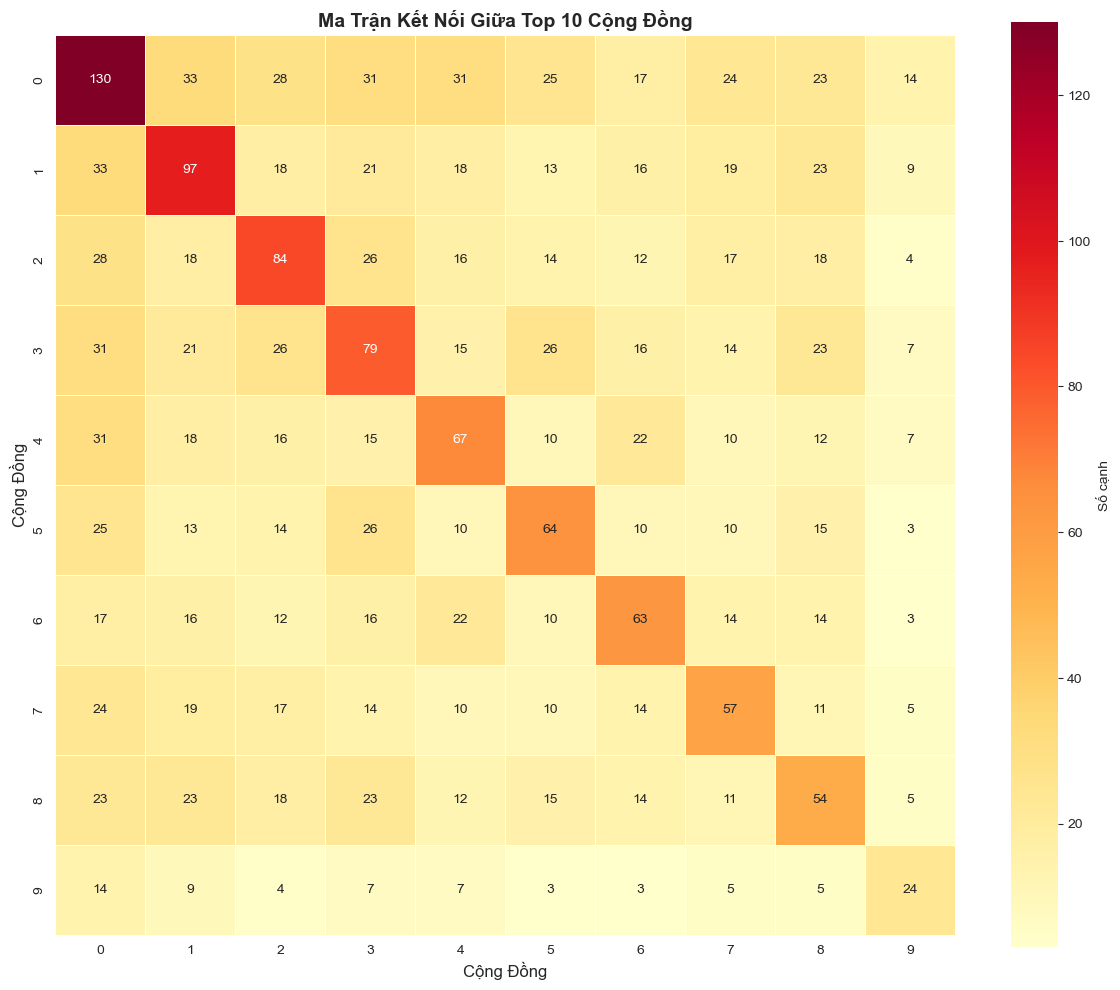


➤ Giải thích:
  - Đường chéo: Số cạnh nội bộ trong mỗi cộng đồng
  - Ngoài đường chéo: Số cạnh liên kết giữa các cộng đồng
  - Giá trị cao ngoài đường chéo = hai cộng đồng có kết nối chặt


In [ ]:
print("\n" + "="*70)
print("PHÂN TÍCH KẾT NỐI GIỮA CÁC CỘNG ĐỒNG")
print("="*70)

# Đếm internal và external edges
internal_edges = 0
external_edges = 0

for u, v in G.edges():
    if node_to_community[u] == node_to_community[v]:
        internal_edges += 1
    else:
        external_edges += 1

total_edges = G.number_of_edges()

print(f"\nThống kê cạnh:")
print(f"  Cạnh nội bộ (intra-community): {internal_edges:,} ({internal_edges/total_edges*100:.1f}%)")
print(f"  Cạnh liên cộng đồng (inter-community): {external_edges:,} ({external_edges/total_edges*100:.1f}%)")
print(f"  Tổng cạnh: {total_edges:,}")

# Ma trận kết nối giữa các cộng đồng (top communities)
top_n_comm = 10
top_comms = sorted(best_communities, key=len, reverse=True)[:top_n_comm]

# Tạo mapping
comm_to_idx = {}
idx = 0
for comm in top_comms:
    for node in comm:
        comm_to_idx[node] = idx
    idx += 1

# Ma trận kết nối
conn_matrix = np.zeros((top_n_comm, top_n_comm))

for u, v in G.edges():
    if u in comm_to_idx and v in comm_to_idx:
        i = comm_to_idx[u]
        j = comm_to_idx[v]
        conn_matrix[i, j] += 1
        if i != j:
            conn_matrix[j, i] += 1

# Vẽ heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(conn_matrix, annot=True, fmt='.0f', cmap='YlOrRd', 
            square=True, linewidths=0.5, cbar_kws={'label': 'Số cạnh'})
plt.xlabel('Cộng Đồng', fontsize=12)
plt.ylabel('Cộng Đồng', fontsize=12)
plt.title(f'Ma Trận Kết Nối Giữa Top {top_n_comm} Cộng Đồng', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n➤ Giải thích:")
print(f"  - Đường chéo: Số cạnh nội bộ trong mỗi cộng đồng")
print(f"  - Ngoài đường chéo: Số cạnh liên kết giữa các cộng đồng")
print(f"  - Giá trị cao ngoài đường chéo = hai cộng đồng có kết nối chặt")